# GBPUSD V. EURUSD

### GOOGLE DRIVE

In [1]:
from google.colab import drive
import sys, os, shutil, subprocess

drive.mount('/content/drive')

REPO_ROOT  = '/content/stk-mat2011'
REPO_DATA  = f'{REPO_ROOT}/code/data/processed'
DRIVE_DATA = '/content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed'

# 1. Clone (or pull if already cloned this session)
if not os.path.isdir(REPO_ROOT):
    subprocess.run(['git', 'clone', 'https://github.com/egil10/stk-mat2011.git', REPO_ROOT], check=True)
else:
    subprocess.run(['git', '-C', REPO_ROOT, 'pull'], check=True)

# 2. Replace empty data dir from clone with symlink to Drive
if os.path.isdir(REPO_DATA) and not os.path.islink(REPO_DATA):
    shutil.rmtree(REPO_DATA)
if os.path.islink(REPO_DATA) and not os.path.exists(REPO_DATA):
    os.unlink(REPO_DATA)  # broken symlink
if not os.path.islink(REPO_DATA):
    os.symlink(DRIVE_DATA, REPO_DATA)

# 3. Set up imports + working directory to match local notebook environment
sys.path.append(f'{REPO_ROOT}/code/scripts')
os.chdir(f'{REPO_ROOT}/code/notebooks')   # ← key change: mimics local CWD

# 4. Sanity check
print(f"CWD:           {os.getcwd()}")
print(f"wfo.py:        {os.path.isfile(f'{REPO_ROOT}/code/scripts/wfo.py')}")
print(f"Data symlink:  {os.path.islink(REPO_DATA)} → {os.readlink(REPO_DATA) if os.path.islink(REPO_DATA) else 'N/A'}")
print(f"Parquet count: {len([f for f in os.listdir(REPO_DATA) if f.endswith('.parquet')])}")
print(f"Path test:     {os.path.exists('../data/processed/audusd_dukascopy_ask_202401.parquet')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CWD:           /content/stk-mat2011/code/notebooks
wfo.py:        True
Data symlink:  True → /content/drive/MyDrive/GITHUB-COPILOT/stk-mat2011/data/processed
Parquet count: 914
Path test:     True


### IMPORT

In [ ]:
%%capture
!pip install arch optuna

import os, sys, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from arch import arch_model

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", module="statsmodels.tsa.base.tsa_model")

# scripts already on sys.path from Cell 2 — but keep this for parity with local notebook
sys.path.append(os.path.abspath('../scripts'))

from spread import SPREAD
from screener import SCREENER
from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from descriptive import DESCRIPTIVE
from wfo import WFO

### PARAMS

In [ ]:
# ==========================================
# 1. CORE ASSET CONFIG (NOK/SEK)
# ==========================================
NAME_A, NAME_B = "EURNOK", "EURSEK"
ACTIVE_HOURS = (9, 15)    # European Session core hours
BAR_THRESHOLD = 1000      # Tick-aggregation volume threshold

# EDA & Screener Defaults
EDA_THRESHOLD = 1000
ROLLING_WINDOW = 2000
ROLLING_STEP = 200

# ==========================================
# 2. ADAPTIVE MATH (ENGINE)
# ==========================================
TRAIN_DAYS = 30           # Daily rolling training history
COINT_WINDOW = 300        # Capture microstructure cointegration
Z_WINDOW = 100            # Mean-reversion lookback window

# HMM Architecture (Locked via Synthetic Diagnostics)
K_REGIMES = 2
WINSORIZE_STD = 4.0       # Stabilizes solver against high Scandinavian kurtosis
SCALING = 10000           # Standard portfolio-wide scaling

# ==========================================
# 3. ADAPTIVE RULES (WFO MANAGER)
# ==========================================
# WFO is critical here to see if the pair EVER regains mean-reversion.
VAL_MONTHS = 3            # Look back 3 months to find optimal execution
TEST_MONTHS = 1           # Apply optimized rules to the next 1 month
N_TRIALS = 100            # Trials per month

In [ ]:
DATA_DIR = "../data/processed"

def make_files(name_a, name_b, months):
    """Build the [ask_a, bid_a, ask_b, bid_b] file list for a pair across given months."""
    a, b = name_a.lower(), name_b.lower()
    return [
        [f"{DATA_DIR}/{a}_dukascopy_ask_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{a}_dukascopy_bid_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{b}_dukascopy_ask_{m}.parquet" for m in months],
        [f"{DATA_DIR}/{b}_dukascopy_bid_{m}.parquet" for m in months],
    ]

### EDA

built 10106 rows

=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 9:00 to 12:00 UTC
Overall Median Spread: A=0.77 | B=0.90 bps


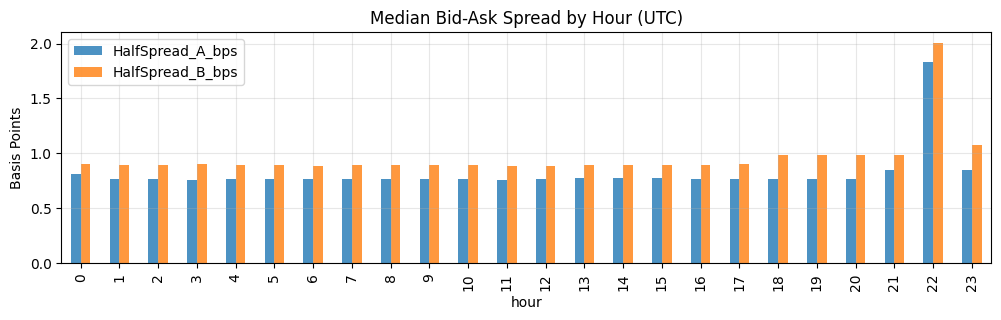


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)      Skew   Kurtosis
AUDUSD   -0.046397   3.802624 -0.522662  10.282642
NZDUSD   -0.037574   3.932509 -0.863125  14.185103

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


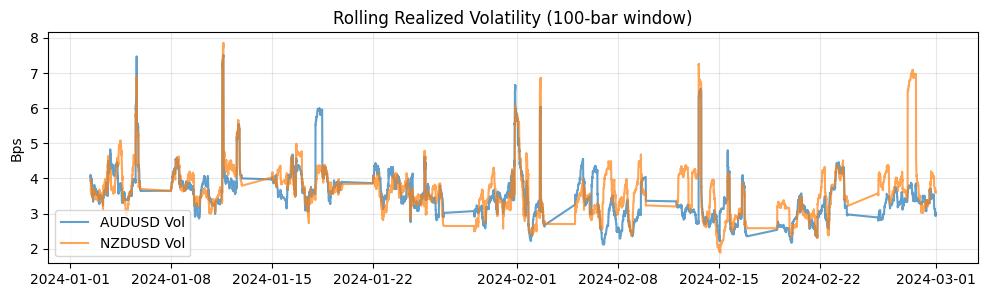

In [ ]:
eda_months = ["202401", "202402"]
eda_files = make_files(NAME_A, NAME_B, eda_months)

builder_eda = SPREAD(agg_type='volume', threshold=EDA_THRESHOLD, active_hours=(EDA_START_HOUR, EDA_END_HOUR))
df_raw_eda = builder_eda.build(eda_files)

eda = DESCRIPTIVE(df_raw_eda, NAME_A, NAME_B)
eda.generate_full_eda()

### DATA

In [ ]:
months = [
    "202401", "202402", "202403", "202404", "202405", "202406",
    "202407", "202408", "202409", "202410", "202411", "202412",
    "202501", "202502", "202503", "202504", "202505", "202506",
    "202507", "202508", "202509", "202510", "202511", "202512",
]

my_files = make_files(NAME_A, NAME_B, months)

### SPREAD

built 50027 rows


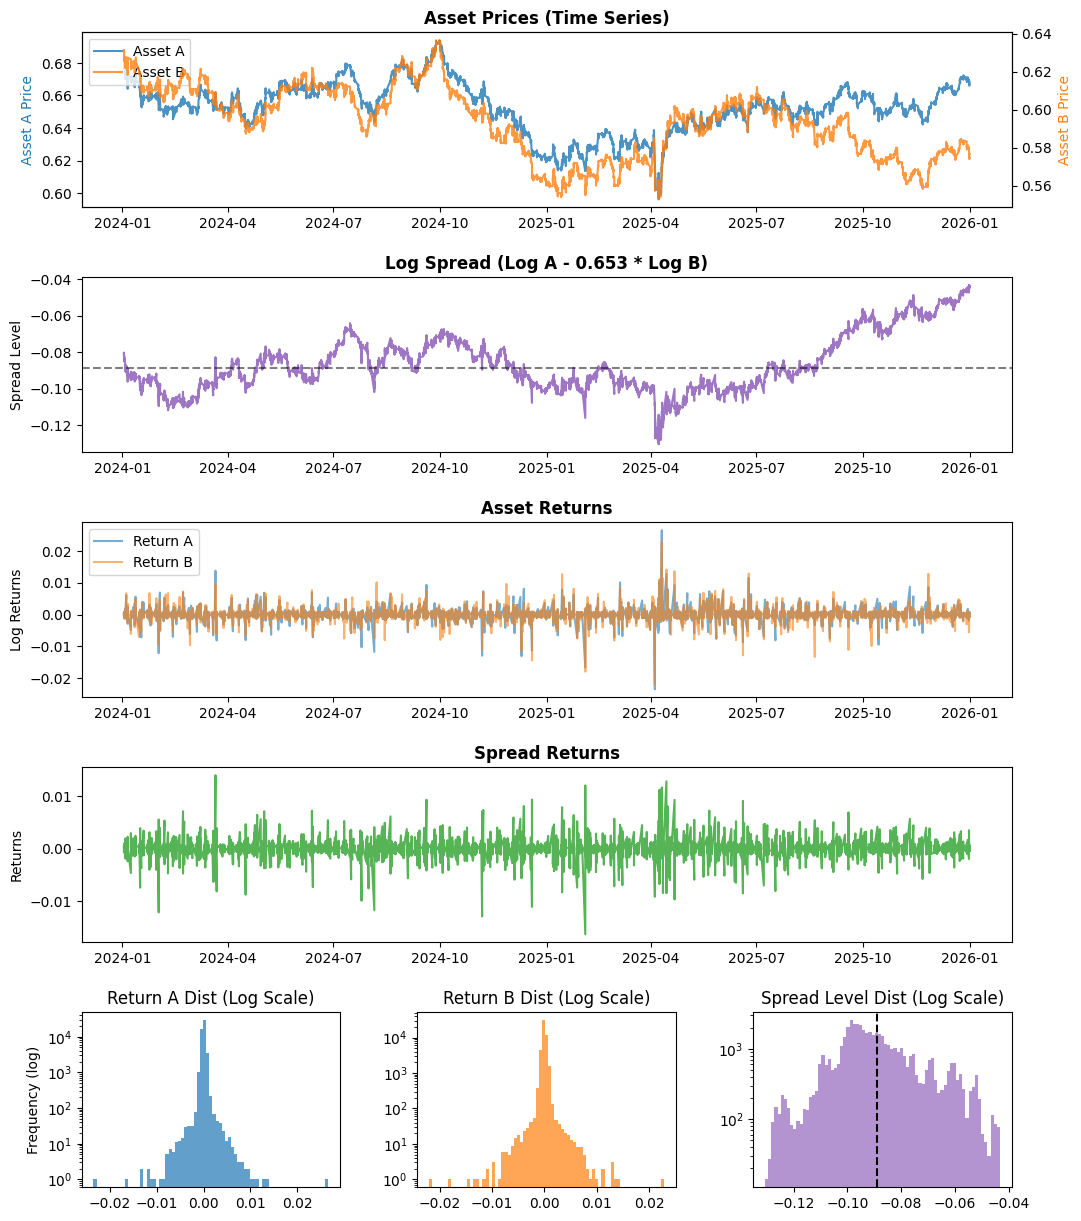

In [6]:
builder = SPREAD(agg_type='volume', threshold=THRESHOLD, active_hours=(START_HOUR, END_HOUR))
df = builder.build(my_files)
builder.plot_diagnostics()

### DESCRIPTIVE


=== LIQUIDITY PROFILE (Median Spreads) ===
Tightest 4h Window: 11:00 to 14:00 UTC
Overall Median Spread: A=0.75 | B=0.87 bps


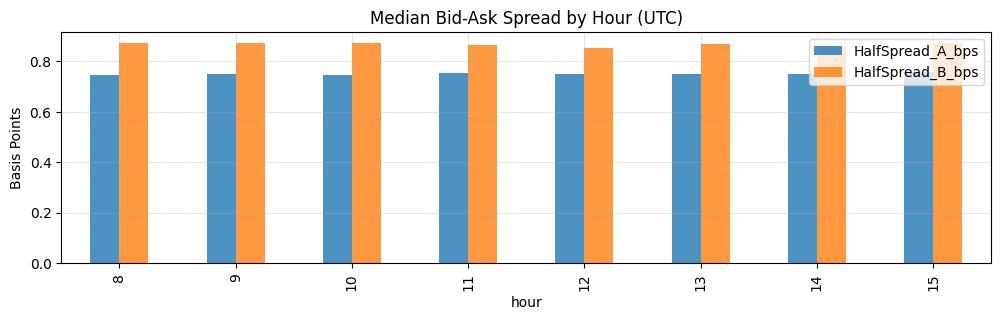


=== RETURN STATISTICS (Log Scale) ===
        Mean (bps)  Vol (bps)      Skew    Kurtosis
AUDUSD   -0.004734   5.846165  0.149936  224.154253
NZDUSD   -0.018571   6.005629 -0.195559  185.364850

[!] WARNING: High Kurtosis detected (>10). Gaussian Markov Models (HMM) 
    will likely struggle with false-positive 'Danger' regimes.


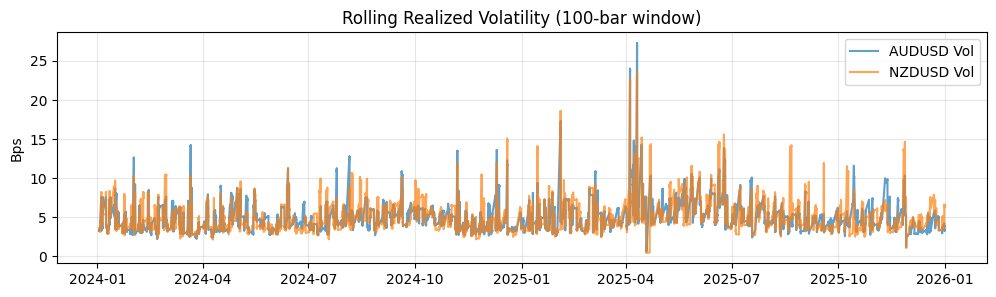

In [ ]:
eda = DESCRIPTIVE(df, name_a=NAME_A, name_b=NAME_B)
eda.generate_full_eda()

### SCREENER


=== COINTEGRATION SCREENER ===
Full: p=0.8808 | half-life=1176.5 | β=0.6527

Rolling (2000-bar, step 200, n=241):
  p<0.05: 6.2% | p<0.10: 12.9%
  half-life: 45.3 (IQR 20–84)
  β: 0.7671 ±0.2896 [-0.1284, 1.3978]


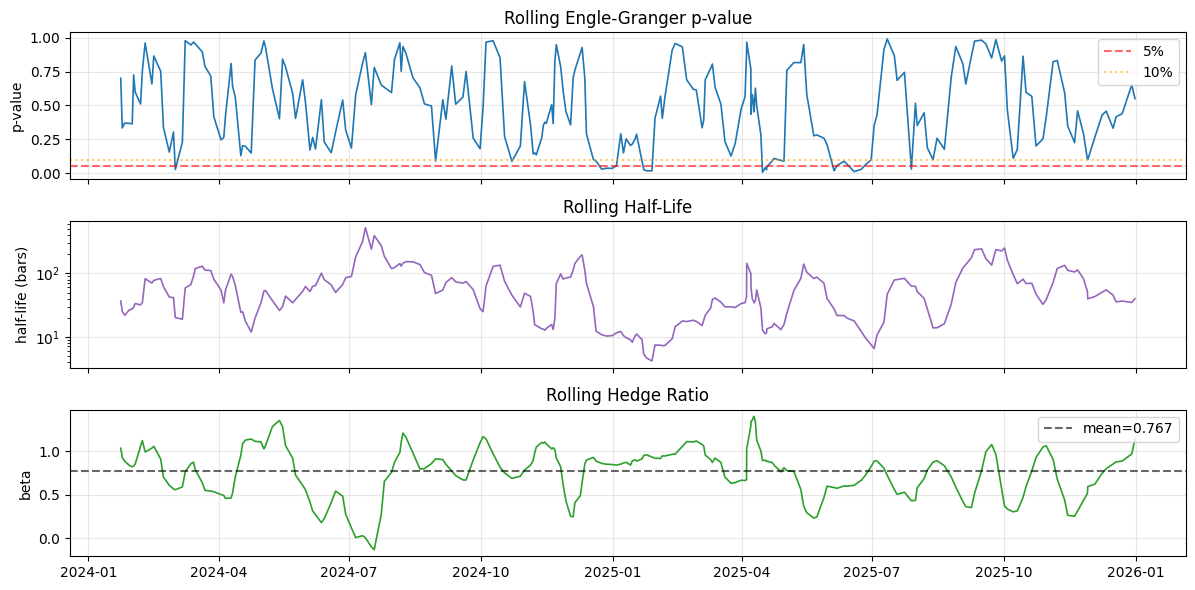

In [8]:
screener = SCREENER(df['Asset_A'], df['Asset_B'])
p_val, hl = screener.generate_report(rolling_window=ROLLING_WINDOW, rolling_step=ROLLING_STEP)

### RELOAD MODULES

In [9]:
import importlib
import engine, backtester, tearsheet, wfo

importlib.reload(engine)
importlib.reload(backtester)
importlib.reload(tearsheet)
importlib.reload(wfo)

from engine import ENGINE
from backtester import BACKTESTER
from tearsheet import TEARSHEET
from wfo import WFO

### LIVE TRADING

In [10]:
live_trading_data, df_params = ENGINE.walk_forward(
    df=df,
    train_days=TRAIN_DAYS,
    coint_window=COINT_WINDOW,
    z_window=Z_WINDOW,
    k_regimes=K_REGIMES,
    winsorize_std=WINSORIZE_STD,
    scaling=SCALING
)

Running Engine | train_days=30 | coint_window=300 | z_window=100
[2024-02-13] Beta: 0.4579 | AR: 0.9516
[2024-02-27] Beta: 0.9868 | AR: 0.9532
[2024-03-12] Beta: 1.0933 | AR: 0.9280
[2024-03-26] Beta: 0.9349 | AR: 0.9295
[2024-04-09] Beta: 1.0562 | AR: 0.9271
[2024-04-23] Beta: 0.6488 | AR: 0.9454
[2024-05-07] Beta: 0.8902 | AR: 0.9091
[2024-05-21] Beta: 0.6293 | AR: 0.8882
[2024-06-04] Beta: 0.7159 | AR: 0.9411
[2024-06-18] Beta: 0.8808 | AR: 0.9512
[2024-07-02] Beta: 0.6600 | AR: 0.9672
[2024-07-16] Beta: 0.4219 | AR: 0.9561
[2024-07-30] Beta: 0.7687 | AR: 0.9644
[2024-08-13] Beta: 0.8240 | AR: 0.9751
[2024-08-27] Beta: 0.6855 | AR: 0.9770
[2024-09-10] Beta: 0.9084 | AR: 0.9790
[2024-09-24] Beta: 1.0324 | AR: 0.9503
[2024-10-08] Beta: 0.7086 | AR: 0.9239
[2024-10-22] Beta: 0.7791 | AR: 0.9264
[2024-11-05] Beta: 1.0358 | AR: 0.9499
[2024-11-19] Beta: 0.6208 | AR: 0.9087
[2024-12-03] Beta: 0.9328 | AR: 0.9319
[2024-12-17] Beta: 0.9351 | AR: 0.9473
[2025-01-02] Beta: 0.5841 | AR: 0.9383

### BACKTESTER w/ WFO

In [11]:
from wfo import WFO

wfo = WFO(live_trading_data)
results_wfo = wfo.run_wfo(val_months=VAL_MONTHS, test_months=TEST_MONTHS, n_trials=N_TRIALS)

WFO setup: 3mo train / 1mo test
  Windows:  21
  Trials:   100 per window
  Period:   2024-05-10 → 2025-12-31

  #  Test window                 Best Sharpe   Entry Z   Exit Z   Danger   AR lim     OOS ret
---------------------------------------------------------------------------------------------


WFO windows:   0%|          | 0/21 [00:00<?, ?it/s]

  1  2024-05-10 → 2024-06-07          22.592      1.90     0.50     0.95    0.980      0.0069
  2  2024-06-10 → 2024-07-08          21.322      1.20    -0.30     0.95    0.960      0.0071
  3  2024-07-09 → 2024-08-06          30.735      1.00     0.40     0.95    0.980     -0.0058
  4  2024-08-07 → 2024-09-04          17.625      1.20    -0.20     0.80    0.930      0.0000
  5  2024-09-05 → 2024-10-03          12.814      1.80    -0.50     0.75    0.990      0.0382
  6  2024-10-04 → 2024-11-01          17.573      1.80    -0.50     0.85    0.980      0.0080
  7  2024-11-04 → 2024-12-02          18.845      2.50    -0.50     0.90    0.990      0.0300
  8  2024-12-03 → 2025-01-02          18.600      1.70    -0.20     0.80    0.980      0.0456
  9  2025-01-03 → 2025-01-31          19.931      1.10    -0.10     0.90    0.970      0.0464
 10  2025-02-03 → 2025-03-03          21.806      1.10    -0.10     0.90    0.950      0.0264
 11  2025-03-04 → 2025-04-01          24.025      1.00    -0

### TEARSHEET


                      QUANTITATIVE STRATEGY TEARSHEET                      
Metric                         | Baseline     | AR           | MS_AR        |
-----------------------------------------------------------------------------

--- FINANCIAL METRICS ---
Total Return (bps)             | 6731.69      | 6169.16      | 3439.03      |
Annual Return (bps)            | 3982.13      | 3649.36      | 2034.36      |
Annual Volatility (bps)        | 743.65       | 706.88       | 641.76       |
Max Drawdown (bps)             | -278.52      | -278.52      | -303.00      |
Sharpe Ratio                   | 5.35         | 5.16         | 3.17         |
Sortino Ratio                  | 6.45         | 5.88         | 3.27         |
Calmar Ratio                   | 14.30        | 13.10        | 6.71         |
Gross Profit (bps)             | 44953.20     | 39570.77     | 35579.02     |
Gross Loss (bps)               | 38221.51     | 33401.62     | 32139.99     |
Profit Factor                  | 1.18 

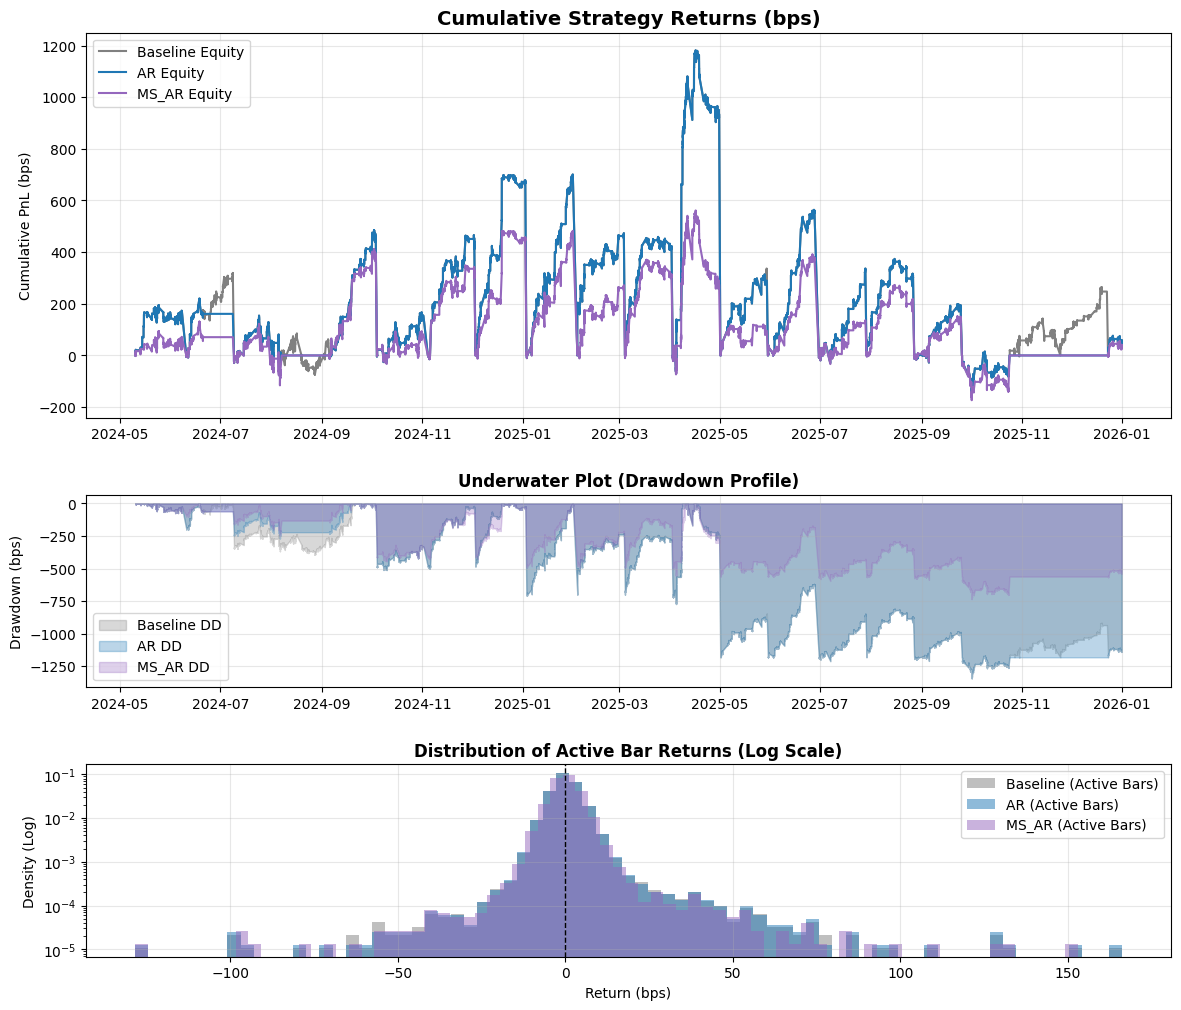

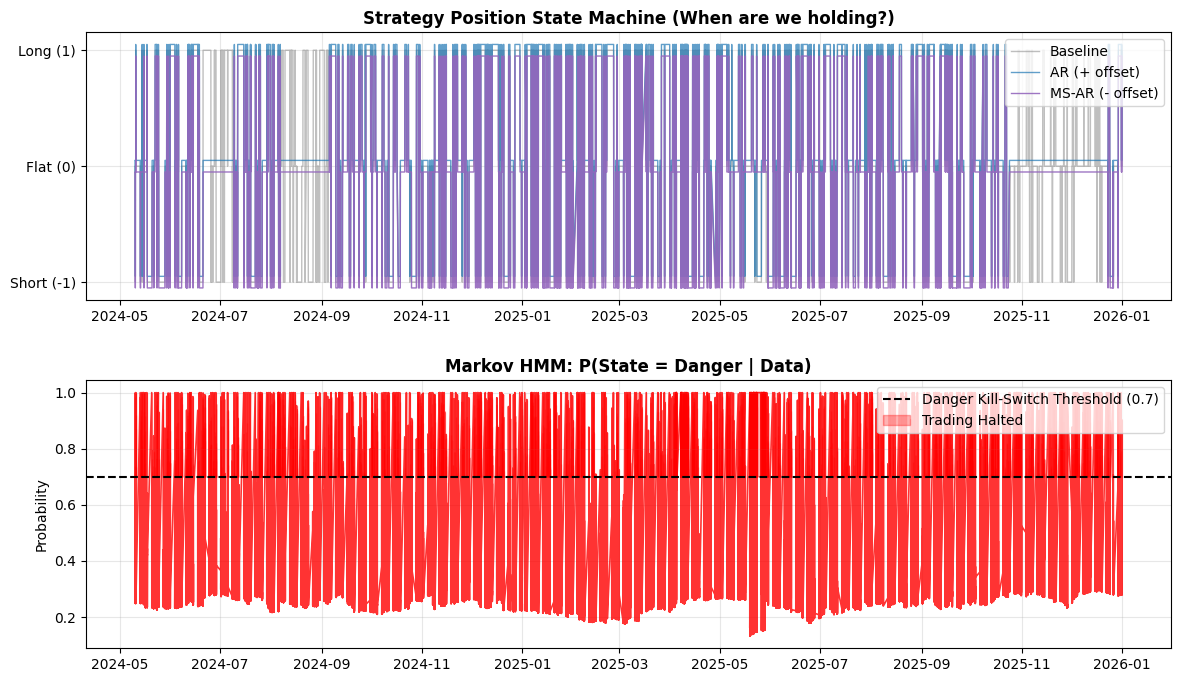

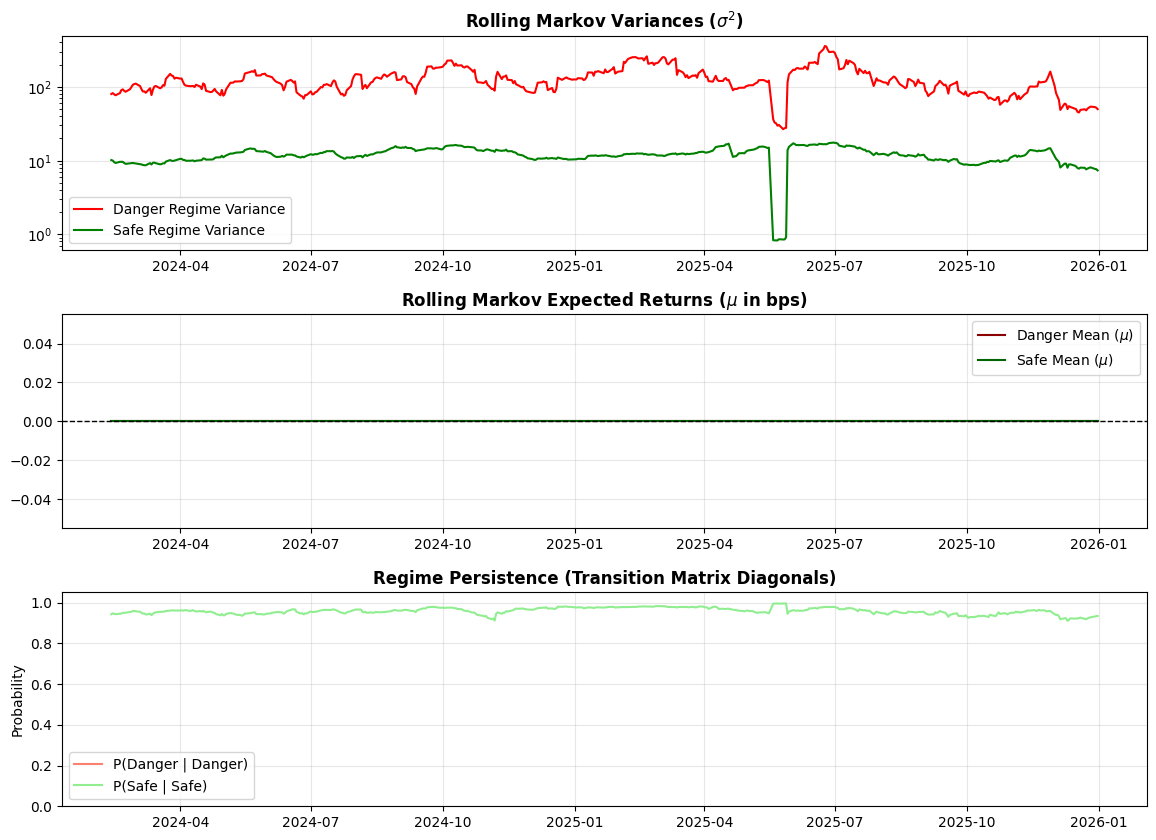

In [12]:
ts = TEARSHEET(results_wfo, df_params=df_params)
ts.generate_report()
ts.plot_performance()
ts.plot_positions_and_regimes()
ts.plot_markov_dynamics()